# Four-Pole Analog Filter Frequency Responses

This notebook models a four-pole analog lowpass core (two cascaded second-order sections) inside a single feedback loop and plots Bode magnitude (dB) and phase responses. Frequency units are Hz.

Equations:
- Second-order section: H(s) = omega0^2 / (s^2 + (omega0/Q) s + omega0^2)
- Core G(s) = H1(s) * H2(s)
- Closed-loop H_cl(s) = G(s) / (1 + k * G(s))  (negative feedback with scalar gain k)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from ipywidgets import interact, FloatLogSlider, FloatSlider
%matplotlib inline

plt.rcParams.update({'figure.figsize': (8, 4), 'grid.linestyle': ':'})

In [ ]:
def two_pole_coeffs(f0_hz, Q):
    w0 = 2 * np.pi * f0_hz
    b = [w0**2]
    a = [1.0, w0 / Q, w0**2]
    return np.array(b, dtype=float), np.array(a, dtype=float)

def cascade_sections(b1, a1, b2, a2):
    b = np.polymul(b1, b2)
    a = np.polymul(a1, a2)
    return b, a

def closed_loop(b, a, k):
    # H_cl = (b/a) / (1 + k * (b/a)) = b / (a + k*b)
    a_cl = np.polyadd(a, k * b)
    b_cl = b.copy()
    return b_cl, a_cl

def bode_db_deg(b, a, f_hz=None, fmin=1.0, fmax=200e3, n=1000):
    if f_hz is None:
        f_hz = np.logspace(np.log10(fmin), np.log10(fmax), n)
    w = 2 * np.pi * f_hz
    w_out, h = signal.freqs(b, a, w)
    mag_db = 20.0 * np.log10(np.abs(h) + 1e-20)
    phase_deg = np.unwrap(np.angle(h)) * 180.0 / np.pi
    return f_hz, mag_db, phase_deg

def plot_bode(f, mag_db, phase_deg, title=None, axmag=None, axphase=None):
    if axmag is None or axphase is None:
        fig, (axmag, axphase) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axmag.semilogx(f, mag_db)
    axmag.set_ylabel('Magnitude (dB)')
    axmag.grid(True, which='both')
    # enforce lower magnitude limit of -100 dB
    try:
        ymax = np.max(mag_db) + 6
    except Exception:
        ymax = axmag.get_ylim()[1]
    if ymax <= -100:
        ymax = -20
    axmag.set_ylim(-100, ymax)
    axphase.semilogx(f, phase_deg)
    axphase.set_ylabel('Phase (deg)')
    axphase.set_xlabel('Frequency (Hz)')
    axphase.grid(True, which='both')
    if title:
        axmag.set_title(title)
    plt.tight_layout()
    return axmag, axphase

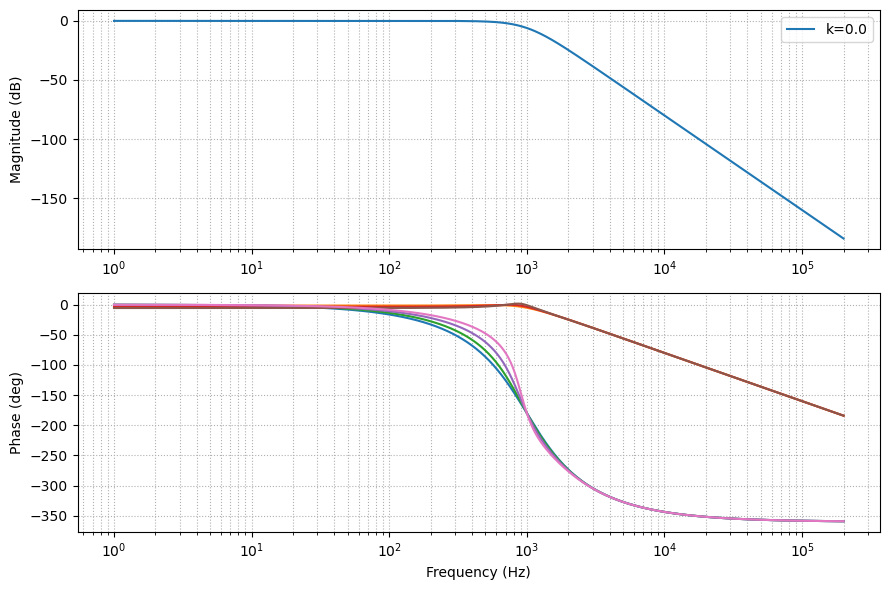

In [ ]:
# Default parameters
f0 = 1000.0  # Hz
Q1 = 0.707
Q2 = 0.707
ks = [0.0, 0.2, 0.5, 0.9]

# Build core G(s) as cascade of two identical 2nd-order sections
b1, a1 = two_pole_coeffs(f0, Q1)
b2, a2 = two_pole_coeffs(f0, Q2)
b_core, a_core = cascade_sections(b1, a1, b2, a2)

# Plot core alone and closed-loop for a few k values
fig, (axmag, axphase) = plt.subplots(2, 1, sharex=True, figsize=(9, 6), gridspec_kw={'height_ratios': [2, 1]})
for k in ks:
    b_cl, a_cl = closed_loop(b_core, a_core, k)
    f, mag_db, phase_deg = bode_db_deg(b_cl, a_cl)
    axmag.semilogx(f, mag_db, label=f'k={k}')
    axphase.semilogx(f, phase_deg, label=f'k={k}')

axmag.set_ylabel('Magnitude (dB)')
axmag.grid(True, which='both')
axmag.legend()
# enforce lower magnitude limit of -100 dB after plotting
ymax = axmag.get_ylim()[1]
axmag.set_ylim(-100, ymax)

axphase.set_ylabel('Phase (deg)')
axphase.set_xlabel('Frequency (Hz)')
axphase.grid(True, which='both')
plt.tight_layout()
plt.savefig('403_filter/frequency_responses_k_sweep.png', dpi=150)
plt.show()

In [5]:
# Interactive controls for k, f0, and Q
def interactive_bode(k=0.2, f0_hz=1000.0, Q=0.707):
    b1, a1 = two_pole_coeffs(f0_hz, Q)
    b2, a2 = two_pole_coeffs(f0_hz, Q)
    b_core, a_core = cascade_sections(b1, a1, b2, a2)
    b_cl, a_cl = closed_loop(b_core, a_core, k)
    f, mag_db, phase_deg = bode_db_deg(b_cl, a_cl)
    plot_bode(f, mag_db, phase_deg, title=f'Closed-loop Bode (k={k:.3f}, f0={f0_hz:.1f} Hz, Q={Q:.3f})')

interact(interactive_bode,
         k=FloatSlider(value=0.2, min=0.0, max=1.0, step=0.01, description='k'),
         f0_hz=FloatLogSlider(value=1000.0, base=10, min=0, max=5, step=0.01, description='f0 (Hz)'),
         Q=FloatSlider(value=0.707, min=0.1, max=5.0, step=0.01, description='Q'))

interactive(children=(FloatSlider(value=0.2, description='k', max=1.0, step=0.01), FloatLogSlider(value=1000.0…

<function __main__.interactive_bode(k=0.2, f0_hz=1000.0, Q=0.707)>